In [1]:
# Imports

%load_ext autoreload
%autoreload 2

import random

from pathlib import Path

from collections import defaultdict

import numpy as np

import pandas as pd

import networkx as nx

from tqdm import tqdm

import community_detection_utils as cdu

import matplotlib.pyplot as plt



In [2]:
# ============================================================
# CELL 1 — IMPORT, LOAD, AND BUILD DBLP BENCHMARK
# ============================================================
# ------------------------------------------------------------
# 1. Imports and configuration
# ------------------------------------------------------------






RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATASET_NAME = "DBLP"

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "environment.yml").is_file():
    if REPO_ROOT.parent == REPO_ROOT:
        raise FileNotFoundError("Could not locate the repository root.")
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / "data" / "dblp"

RESULTS_DIR = REPO_ROOT / "results" / "dblp"
TABLES_DIR = RESULTS_DIR / "tables"
SENSITIVITY_DIR = RESULTS_DIR / "sensitivity"
FIGURES_DIR = REPO_ROOT / "figures" / "dblp"

for output_dir in (TABLES_DIR, SENSITIVITY_DIR, FIGURES_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

EDGES_FILE = (
    DATA_DIR
    / "com-dblp.ungraph.txt.gz"
)

CMTY_FILE = (
    DATA_DIR
    / "com-dblp.top5000.cmty.txt.gz"
)

EDGE_URL = (
    "https://snap.stanford.edu/data/bigdata/"
    "communities/com-dblp.ungraph.txt.gz"
)

CMTY_URL = (
    "https://snap.stanford.edu/data/bigdata/"
    "communities/com-dblp.top5000.cmty.txt.gz"
)


# Community-selection settings

MIN_COMMUNITY_SIZE = 50
MAX_COMMUNITY_SIZE = 500

COND_MIN = 0.20
COND_MAX = 0.60

N_COMMUNITIES = 25


# Curvature settings

LRC_ONLY_PCT = 10

LRC_COMBO_PCT = 2
ORC_COMBO_PCT = 2

ALPHA = 0.5
ORC_ITERATIONS = 5

SEEDS = [
    0,
    1,
    2,
    3,
    4,
    42,
]


# ------------------------------------------------------------
# 2. Download data
# ------------------------------------------------------------

cdu.download_if_missing(
    EDGE_URL,
    EDGES_FILE,
)

cdu.download_if_missing(
    CMTY_URL,
    CMTY_FILE,
)


# ------------------------------------------------------------
# 3. Load full DBLP graph and communities
# ------------------------------------------------------------

G_full = nx.Graph()

for chunk in tqdm(
    cdu.stream_edges(EDGES_FILE),
    desc="Loading DBLP graph",
):
    G_full.add_edges_from(
        chunk[
            [
                "u",
                "v",
            ]
        ].itertuples(
            index=False,
            name=None,
        )
    )

G_full.remove_edges_from(
    nx.selfloop_edges(G_full)
)

communities = cdu.load_communities(
    CMTY_FILE,
    min_size=1,
)


print(G_full)

print(
    "Total communities:",
    len(communities),
)

print(
    "Connected components:",
    nx.number_connected_components(G_full),
)

print(
    "Largest component size:",
    len(
        max(
            nx.connected_components(G_full),
            key=len,
        )
    ),
)


# ------------------------------------------------------------
# 4. Compute structural metrics for all DBLP communities
# ------------------------------------------------------------

rows = []

for cid, nodes in tqdm(
    list(
        enumerate(communities)
    ),
    desc="Computing DBLP community metrics",
):
    metrics = cdu.compute_community_metrics(
        G_full,
        nodes,
    )

    if metrics is not None:
        metrics[
            "community_id"
        ] = cid

        rows.append(
            metrics
        )


metric_df = pd.DataFrame(
    rows
)

metric_df = metric_df[
    np.isfinite(
        metric_df[
            "conductance"
        ]
    )
].copy()


# ------------------------------------------------------------
# 5. Filter candidate communities
# ------------------------------------------------------------

candidate_df = metric_df[
    (
        metric_df[
            "size"
        ]
        >= MIN_COMMUNITY_SIZE
    )
    &
    (
        metric_df[
            "size"
        ]
        <= MAX_COMMUNITY_SIZE
    )
    &
    (
        metric_df[
            "conductance"
        ]
        >= COND_MIN
    )
    &
    (
        metric_df[
            "conductance"
        ]
        <= COND_MAX
    )
].copy()


print(
    "Candidate communities:",
    len(candidate_df),
)

display(
    candidate_df.describe()
)


# ------------------------------------------------------------
# 6. Select communities reproducibly
# ------------------------------------------------------------

if len(candidate_df) < N_COMMUNITIES:
    raise ValueError(
        "Not enough candidate communities. "
        "Relax the filters."
    )


rng = np.random.default_rng(
    RANDOM_SEED
)

picked_ids = rng.choice(
    candidate_df[
        "community_id"
    ].tolist(),
    size=N_COMMUNITIES,
    replace=False,
).tolist()

picked_ids = sorted(
    picked_ids
)


selected_df = candidate_df[
    candidate_df[
        "community_id"
    ].isin(
        picked_ids
    )
].copy()


display(
    selected_df[
        [
            "community_id",
            "size",
            "conductance",
            "BTD",
            "internal_edges",
            "boundary_edges",
        ]
    ]
)


# ------------------------------------------------------------
# 7. Build the selected DBLP benchmark graph
# ------------------------------------------------------------

node_to_cids = defaultdict(
    list
)

for cid in picked_ids:
    for node in communities[cid]:
        if node in G_full:
            node_to_cids[
                node
            ].append(
                cid
            )


nodes_of_interest = set(
    node_to_cids.keys()
)

H_raw = G_full.subgraph(
    nodes_of_interest
).copy()


print(
    "Before GCC:"
)

print(
    "Nodes:",
    H_raw.number_of_nodes(),
)

print(
    "Edges:",
    H_raw.number_of_edges(),
)

print(
    "Components:",
    nx.number_connected_components(
        H_raw
    ),
)


# Use shared GCC function from the module

H0 = cdu.get_gcc(
    H_raw
)


print(
    "After GCC:"
)

print(
    "Nodes:",
    H0.number_of_nodes(),
)

print(
    "Edges:",
    H0.number_of_edges(),
)

print(
    "Components:",
    nx.number_connected_components(
        H0
    ),
)


# ------------------------------------------------------------
# 8. Assign one evaluation label to each node
# ------------------------------------------------------------

cid_to_label = {
    cid: label
    for label, cid in enumerate(
        picked_ids
    )
}

community_size = {
    cid: len(
        communities[cid]
    )
    for cid in picked_ids
}


for node in H0.nodes():

    node_cids = node_to_cids.get(
        node,
        [],
    )

    if len(node_cids) == 0:
        continue

    # For overlapping nodes, assign the smallest selected
    # community, matching the original notebook.
    best_cid = min(
        node_cids,
        key=lambda cid: community_size[
            cid
        ],
    )

    H0.nodes[
        node
    ][
        "label_gt"
    ] = cid_to_label[
        best_cid
    ]

    H0.nodes[
        node
    ][
        "original_cids"
    ] = node_cids

    H0.nodes[
        node
    ][
        "is_overlap"
    ] = int(
        len(node_cids) > 1
    )


labels = [
    H0.nodes[
        node
    ][
        "label_gt"
    ]
    for node in H0.nodes()
    if "label_gt"
    in H0.nodes[node]
]


print(
    "Labeled nodes:",
    len(labels),
)

print(
    "Number of labels:",
    len(
        set(labels)
    ),
)

print(
    "Overlap fraction:",
    np.mean(
        [
            H0.nodes[
                node
            ].get(
                "is_overlap",
                0,
            )
            for node in H0.nodes()
        ]
    ),
)


display(
    pd.Series(
        labels
    ).value_counts()
)


# Final benchmark graph used by later cells

H = H0.copy()


print(
    f"\nFinal DBLP benchmark: "
    f"|V|={H.number_of_nodes():,}, "
    f"|E|={H.number_of_edges():,}"
)

Downloading: https://snap.stanford.edu/data/bigdata/communities/com-dblp.ungraph.txt.gz
Saved: /home/josejgarcia/Documents/Git_Hub_Repos/curvature-guided-community-detection/data/dblp/com-dblp.ungraph.txt.gz
Downloading: https://snap.stanford.edu/data/bigdata/communities/com-dblp.top5000.cmty.txt.gz
Saved: /home/josejgarcia/Documents/Git_Hub_Repos/curvature-guided-community-detection/data/dblp/com-dblp.top5000.cmty.txt.gz


Loading DBLP graph: 2it [00:02,  1.11s/it]


Graph with 317080 nodes and 1049866 edges
Total communities: 5000
Connected components: 1
Largest component size: 317080


Computing DBLP community metrics: 100%|██████████| 5000/5000 [00:01<00:00, 2750.48it/s]

Candidate communities: 33


,size,internal_edges,boundary_edges,boundary_triangles,internal_triangles,conductance,BTD,community_id
count,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,195.545455,544.484848,937.636364,4956.272727,3594.878788,0.433459,5.482009,1895.424242
std,119.086652,361.562073,762.844259,4445.725878,4922.736185,0.090361,3.331806,810.546923
min,52.000000,103.000000,92.000000,375.000000,173.000000,0.222945,2.564246,486.000000
25%,80.000000,225.000000,319.000000,1556.000000,997.000000,0.373887,3.668950,1552.000000
50%,189.000000,567.000000,706.000000,3844.000000,2431.000000,0.448000,4.840659,1829.000000
75%,260.000000,696.000000,1313.000000,6781.000000,3226.000000,0.509516,5.780655,2080.000000
max,425.000000,1894.000000,3556.000000,21573.000000,21934.000000,0.565884,21.536842,4357.000000


,community_id,size,conductance,BTD,internal_edges,boundary_edges
486,486,64,0.222945,5.771883,657,377
765,765,193,0.454482,7.320031,782,1303
903,903,53,0.448000,4.026786,138,224
1193,1193,54,0.328520,4.840659,186,182
1303,1303,376,0.409245,4.269943,1131,1567
1584,1584,52,0.471483,9.193548,139,248
1599,1599,321,0.374408,5.710808,858,1027
1655,1655,126,0.419795,7.813008,340,492
1718,1718,425,0.500939,4.976968,930,1867
1758,1758,179,0.373887,4.284392,633,756


Before GCC:
Nodes: 4508
Edges: 12863
Components: 1
After GCC:
Nodes: 4508
Edges: 12863
Components: 1
Labeled nodes: 4508
Number of labels: 25
Overlap fraction: 0.007985803016858917


8     423
15    385
4     369
10    358
6     321
14    260
16    228
18    225
12    208
19    191
1     189
9     179
22    157
17    123
23    119
7     118
20    110
11    109
21     79
13     74
0      64
24     60
3      54
2      53
5      52
Name: count, dtype: int64


Final DBLP benchmark: |V|=4,508, |E|=12,863


In [3]:
# ============================================================
# CELL 2 — PREPARE DBLP LRC, ORC, AND COMBO GRAPHS
# ============================================================

print(
    f"Input DBLP benchmark: "
    f"|V|={H.number_of_nodes():,}, "
    f"|E|={H.number_of_edges():,}"
)


# ============================================================
# 1. LRC-ONLY GRAPH
# ============================================================

lrc_info = cdu.prepare_lrc_graph(
    graph=H,
    lrc_pct=LRC_ONLY_PCT,
    print_distribution=True,
)

G_lrc = lrc_info["graph"]

print("\n" + "=" * 60)
print("LRC-only graph prepared")
print("=" * 60)

print(
    f"Output graph: "
    f"|V|={G_lrc.number_of_nodes():,}, "
    f"|E|={G_lrc.number_of_edges():,}"
)

print(
    "Removed LRC edges:",
    lrc_info["removed_lrc"],
)

print(
    "LRC cutoff:",
    lrc_info["cutoff_lrc"],
)

print(
    "Preparation time:",
    f"{lrc_info['prep_time']:.2f} seconds",
)


# ============================================================
# 2. ORC-ONLY GRAPH
# ============================================================

orc_info = cdu.prepare_orc_graph(
    graph=H,
    alpha=ALPHA,
    iterations=ORC_ITERATIONS,
    method="Sinkhorn",
)

G_orc = orc_info["graph"]

print("\n" + "=" * 60)
print("ORC-only graph prepared")
print("=" * 60)

print(
    f"Output graph: "
    f"|V|={G_orc.number_of_nodes():,}, "
    f"|E|={G_orc.number_of_edges():,}"
)

print(
    "Alpha:",
    orc_info["alpha"],
)

print(
    "Ricci-flow iterations:",
    orc_info["iterations"],
)

print(
    "Preparation time:",
    f"{orc_info['prep_time']:.2f} seconds",
)


# ============================================================
# 3. LRC → ORC COMBO GRAPH
# ============================================================

combo_info = cdu.prepare_combo_graph(
    graph=H,
    lrc_pct=LRC_COMBO_PCT,
    orc_pct=ORC_COMBO_PCT,
    alpha=ALPHA,
    iterations=ORC_ITERATIONS,
    method="Sinkhorn",
)

G_combo = combo_info["graph"]

print("\n" + "=" * 60)
print("LRC → ORC combo graph prepared")
print("=" * 60)

print(
    f"Output graph: "
    f"|V|={G_combo.number_of_nodes():,}, "
    f"|E|={G_combo.number_of_edges():,}"
)

print(
    "Removed during LRC pruning:",
    combo_info["removed_lrc"],
)

print(
    "Removed during ORC pruning:",
    combo_info["removed_orc"],
)

print(
    "LRC cutoff:",
    combo_info["cutoff_lrc"],
)

print(
    "ORC cutoff:",
    combo_info["cutoff_orc"],
)

print(
    "Preparation time:",
    f"{combo_info['prep_time']:.2f} seconds",
)


# ============================================================
# 4. GRAPH REDUCTION SUMMARY
# ============================================================

input_nodes = H.number_of_nodes()
input_edges = H.number_of_edges()

prepared_graph_summary = pd.DataFrame(
    [
        {
            "Method": "LRC-only",
            "Input Nodes": input_nodes,
            "Input Edges": input_edges,
            "Output Nodes": G_lrc.number_of_nodes(),
            "Output Edges": G_lrc.number_of_edges(),
            "Node Reduction (%)": (
                100
                * (
                    1
                    - G_lrc.number_of_nodes()
                    / input_nodes
                )
            ),
            "Edge Reduction (%)": (
                100
                * (
                    1
                    - G_lrc.number_of_edges()
                    / input_edges
                )
            ),
            "Preparation Time (s)": (
                lrc_info["prep_time"]
            ),
        },
        {
            "Method": "ORC-only",
            "Input Nodes": input_nodes,
            "Input Edges": input_edges,
            "Output Nodes": G_orc.number_of_nodes(),
            "Output Edges": G_orc.number_of_edges(),
            "Node Reduction (%)": (
                100
                * (
                    1
                    - G_orc.number_of_nodes()
                    / input_nodes
                )
            ),
            "Edge Reduction (%)": (
                100
                * (
                    1
                    - G_orc.number_of_edges()
                    / input_edges
                )
            ),
            "Preparation Time (s)": (
                orc_info["prep_time"]
            ),
        },
        {
            "Method": "LRC→ORC combo",
            "Input Nodes": input_nodes,
            "Input Edges": input_edges,
            "Output Nodes": G_combo.number_of_nodes(),
            "Output Edges": G_combo.number_of_edges(),
            "Node Reduction (%)": (
                100
                * (
                    1
                    - G_combo.number_of_nodes()
                    / input_nodes
                )
            ),
            "Edge Reduction (%)": (
                100
                * (
                    1
                    - G_combo.number_of_edges()
                    / input_edges
                )
            ),
            "Preparation Time (s)": (
                combo_info["prep_time"]
            ),
        },
    ]
)

prepared_graph_summary[
    [
        "Node Reduction (%)",
        "Edge Reduction (%)",
        "Preparation Time (s)",
    ]
] = prepared_graph_summary[
    [
        "Node Reduction (%)",
        "Edge Reduction (%)",
        "Preparation Time (s)",
    ]
].round(2)

print("\nPrepared graph summary:")

display(prepared_graph_summary)


# ============================================================
# 5. BASIC VALIDATION CHECKS
# ============================================================

assert H.number_of_nodes() > 0
assert H.number_of_edges() > 0

assert G_lrc.number_of_nodes() > 0
assert G_lrc.number_of_edges() > 0

assert G_orc.number_of_nodes() > 0
assert G_orc.number_of_edges() > 0

assert G_combo.number_of_nodes() > 0
assert G_combo.number_of_edges() > 0

assert nx.is_connected(G_lrc)
assert nx.is_connected(G_orc)
assert nx.is_connected(G_combo)

print(
    "\nAll prepared graphs are non-empty "
    "and connected."
)

Input DBLP benchmark: |V|=4,508, |E|=12,863
LRC distribution:
count    12863.000000
mean         0.200329
std          0.717040
min         -1.829721
25%         -0.313725
50%          0.169935
75%          0.850000
max          1.500000
dtype: float64

LRC-only graph prepared
Output graph: |V|=465, |E|=1,175
Removed LRC edges: 1302
LRC cutoff: -0.75
Preparation time: 0.48 seconds

ORC-only graph prepared
Output graph: |V|=4,508, |E|=12,863
Alpha: 0.5
Ricci-flow iterations: 5
Preparation time: 58.35 seconds

LRC → ORC combo graph prepared
Output graph: |V|=4,060, |E|=11,206
Removed during LRC pruning: 259
Removed during ORC pruning: 230
LRC cutoff: -1.304761904761905
ORC cutoff: -0.18057575770364143
Preparation time: 51.59 seconds

Prepared graph summary:


,Method,Input Nodes,Input Edges,Output Nodes,Output Edges,Node Reduction (%),Edge Reduction (%),Preparation Time (s)
0,LRC-only,4508,12863,465,1175,89.69,90.87,0.48
1,ORC-only,4508,12863,4508,12863,0.00,0.00,58.35
2,LRC→ORC combo,4508,12863,4060,11206,9.94,12.88,51.59



All prepared graphs are non-empty and connected.


In [4]:
# ============================================================
# CELL 3 — DBLP MULTI-SEED EVALUATION AND RESULT TABLES
# ============================================================

prepared = [
    lrc_info,
    orc_info,
    combo_info,
]


# ============================================================
# 1. SINGLE-SEED RESULTS (SEED = 42)
# ============================================================

single_seed_rows = []

# Plain Louvain
single_seed_rows.append(
    cdu.evaluate_plain_graph(
        graph=H,
        algorithm="louvain",
        seed=RANDOM_SEED,
    )
)

# Plain Leiden
single_seed_rows.append(
    cdu.evaluate_plain_graph(
        graph=H,
        algorithm="leiden",
        seed=RANDOM_SEED,
    )
)

# Curvature-based methods
for info in prepared:

    single_seed_rows.append(
        cdu.evaluate_prepared_graph(
            info=info,
            algorithm="louvain",
            seed=RANDOM_SEED,
        )
    )

    single_seed_rows.append(
        cdu.evaluate_prepared_graph(
            info=info,
            algorithm="leiden",
            seed=RANDOM_SEED,
        )
    )


df_single_seed = pd.DataFrame(
    single_seed_rows
)

print(
    "DBLP single-seed results "
    f"(seed={RANDOM_SEED}):"
)

display(
    df_single_seed[
        [
            "method",
            "algorithm",
            "seed",
            "ARI",
            "NMI",
            "n_eval",
            "V",
            "E",
            "runtime_sec",
            "prep_time",
            "community_time",
            "removed_lrc",
            "removed_orc",
        ]
    ].sort_values(
        "ARI",
        ascending=False,
    )
)

df_single_seed.to_csv(
    TABLES_DIR / 'dblp_single_seed_results.csv',
    index=False,
)


# ============================================================
# 2. MULTI-SEED EVALUATION
# ============================================================

multi_rows = []

for seed in SEEDS:

    print("\n" + "=" * 70)
    print("Seed:", seed)
    print("=" * 70)

    # --------------------------------------------------------
    # Plain Louvain
    # --------------------------------------------------------

    plain_louvain = cdu.evaluate_plain_graph(
        graph=H,
        algorithm="louvain",
        seed=seed,
    )

    multi_rows.append(
        plain_louvain
    )

    print(
        f"{plain_louvain['method']}: "
        f"ARI={plain_louvain['ARI']:.4f}, "
        f"NMI={plain_louvain['NMI']:.4f}, "
        f"Runtime={plain_louvain['runtime_sec']:.2f}s"
    )


    # --------------------------------------------------------
    # Plain Leiden
    # --------------------------------------------------------

    plain_leiden = cdu.evaluate_plain_graph(
        graph=H,
        algorithm="leiden",
        seed=seed,
    )

    multi_rows.append(
        plain_leiden
    )

    print(
        f"{plain_leiden['method']}: "
        f"ARI={plain_leiden['ARI']:.4f}, "
        f"NMI={plain_leiden['NMI']:.4f}, "
        f"Runtime={plain_leiden['runtime_sec']:.2f}s"
    )


    # --------------------------------------------------------
    # LRC, ORC, and Combo with Louvain
    # --------------------------------------------------------

    for info in prepared:

        result = cdu.evaluate_prepared_graph(
            info=info,
            algorithm="louvain",
            seed=seed,
        )

        multi_rows.append(
            result
        )

        print(
            f"{result['method']}: "
            f"ARI={result['ARI']:.4f}, "
            f"NMI={result['NMI']:.4f}, "
            f"Runtime={result['runtime_sec']:.2f}s"
        )


    # --------------------------------------------------------
    # LRC, ORC, and Combo with Leiden
    # --------------------------------------------------------

    for info in prepared:

        result = cdu.evaluate_prepared_graph(
            info=info,
            algorithm="leiden",
            seed=seed,
        )

        multi_rows.append(
            result
        )

        print(
            f"{result['method']}: "
            f"ARI={result['ARI']:.4f}, "
            f"NMI={result['NMI']:.4f}, "
            f"Runtime={result['runtime_sec']:.2f}s"
        )


# ============================================================
# 3. COMPLETE MULTI-SEED DATAFRAME
# ============================================================

df_multi = pd.DataFrame(
    multi_rows
)

print(
    "\nMulti-seed dataframe shape:",
    df_multi.shape,
)

expected_rows = (
    len(SEEDS) * 8
)

assert len(df_multi) == expected_rows, (
    f"Expected {expected_rows} rows, "
    f"but found {len(df_multi)}."
)

display(
    df_multi[
        [
            "method",
            "algorithm",
            "seed",
            "ARI",
            "NMI",
            "n_eval",
            "V",
            "E",
            "runtime_sec",
            "prep_time",
            "community_time",
            "removed_lrc",
            "removed_orc",
        ]
    ].sort_values(
        [
            "seed",
            "method",
        ]
    )
)

df_multi.to_csv(
    TABLES_DIR / 'dblp_multiseed_results.csv',
    index=False,
)


# ============================================================
# 4. NUMERIC MEAN AND STANDARD-DEVIATION SUMMARY
# ============================================================

numeric_summary = (
    df_multi
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        ARI_mean=(
            "ARI",
            "mean",
        ),
        ARI_std=(
            "ARI",
            "std",
        ),
        NMI_mean=(
            "NMI",
            "mean",
        ),
        NMI_std=(
            "NMI",
            "std",
        ),
        Runtime_mean=(
            "runtime_sec",
            "mean",
        ),
        Runtime_std=(
            "runtime_sec",
            "std",
        ),
        Input_Evaluation_Nodes=(
            "n_eval",
            "mean",
        ),
        Output_Nodes=(
            "V",
            "mean",
        ),
        Output_Edges=(
            "E",
            "mean",
        ),
        Prep_Time_mean=(
            "prep_time",
            "mean",
        ),
        Community_Time_mean=(
            "community_time",
            "mean",
        ),
    )
    .sort_values(
        "ARI_mean",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nDBLP numeric summary:"
)

display(
    numeric_summary
)

numeric_summary.to_csv(
    TABLES_DIR / 'dblp_numeric_summary.csv',
    index=False,
)


# ============================================================
# 5. PAPER-STYLE MEAN ± STD TABLE
# ============================================================

paper_table = numeric_summary.copy()

paper_table["ARI"] = (
    paper_table["ARI_mean"].map(
        lambda value: f"{value:.3f}"
    )
    + " ± "
    + paper_table["ARI_std"].map(
        lambda value: f"{value:.3f}"
    )
)

paper_table["NMI"] = (
    paper_table["NMI_mean"].map(
        lambda value: f"{value:.3f}"
    )
    + " ± "
    + paper_table["NMI_std"].map(
        lambda value: f"{value:.3f}"
    )
)

paper_table["Runtime (s)"] = (
    paper_table["Runtime_mean"].map(
        lambda value: f"{value:.2f}"
    )
    + " ± "
    + paper_table["Runtime_std"].map(
        lambda value: f"{value:.2f}"
    )
)

paper_table["Input Nodes"] = (
    H.number_of_nodes()
)

paper_table["Input Edges"] = (
    H.number_of_edges()
)

paper_table["Output Nodes"] = (
    paper_table[
        "Output_Nodes"
    ].round().astype(int)
)

paper_table["Output Edges"] = (
    paper_table[
        "Output_Edges"
    ].round().astype(int)
)

paper_table["Edge Reduction (%)"] = (
    100
    * (
        1
        - paper_table["Output Edges"]
        / H.number_of_edges()
    )
).round(2)

paper_table = paper_table[
    [
        "method",
        "ARI",
        "NMI",
        "Runtime (s)",
        "Input Nodes",
        "Input Edges",
        "Output Nodes",
        "Output Edges",
        "Edge Reduction (%)",
    ]
].rename(
    columns={
        "method": "Method",
    }
)

print(
    "\nDBLP paper-style table:"
)

display(
    paper_table
)

paper_table.to_csv(
    TABLES_DIR / 'dblp_final_mean_std_table.csv',
    index=False,
)


# ============================================================
# 6. THREE-METHOD MAIN PAPER TABLE
# ============================================================

main_methods = [
    "LRC-only",
    "ORC-only",
    "LRC→ORC combo",
]

main_paper_table = (
    paper_table[
        paper_table[
            "Method"
        ].isin(
            main_methods
        )
    ]
    .copy()
)

main_paper_table["Method"] = pd.Categorical(
    main_paper_table["Method"],
    categories=main_methods,
    ordered=True,
)

main_paper_table = (
    main_paper_table
    .sort_values(
        "Method"
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nThree-method DBLP table "
    "for the main article:"
)

display(
    main_paper_table
)

main_paper_table.to_csv(
    TABLES_DIR / 'dblp_main_three_method_table.csv',
    index=False,
)


# ============================================================
# 7. PAIRED STATISTICAL TESTS
# ============================================================

ari_tests_vs_orc = cdu.paired_tests(
    results=df_multi,
    baseline_method="ORC-only",
    metric="ARI",
)

nmi_tests_vs_orc = cdu.paired_tests(
    results=df_multi,
    baseline_method="ORC-only",
    metric="NMI",
)

print(
    "\nPaired ARI tests against ORC-only:"
)

display(
    ari_tests_vs_orc
)

print(
    "\nPaired NMI tests against ORC-only:"
)

display(
    nmi_tests_vs_orc
)

ari_tests_vs_orc.to_csv(
    TABLES_DIR / 'dblp_ari_paired_tests_vs_orc.csv',
    index=False,
)

nmi_tests_vs_orc.to_csv(
    TABLES_DIR / 'dblp_nmi_paired_tests_vs_orc.csv',
    index=False,
)


# ============================================================
# 8. EMPIRICAL RUNTIME AND GRAPH-REDUCTION TABLE
# ============================================================

complexity_table = (
    df_multi
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        Output_Nodes=(
            "V",
            "mean",
        ),
        Output_Edges=(
            "E",
            "mean",
        ),
        Prep_Time=(
            "prep_time",
            "mean",
        ),
        Community_Time=(
            "community_time",
            "mean",
        ),
        Total_Runtime=(
            "runtime_sec",
            "mean",
        ),
        Removed_LRC=(
            "removed_lrc",
            "mean",
        ),
        Removed_ORC=(
            "removed_orc",
            "mean",
        ),
    )
)

complexity_table.insert(
    1,
    "Input_Nodes",
    H.number_of_nodes(),
)

complexity_table.insert(
    2,
    "Input_Edges",
    H.number_of_edges(),
)

complexity_table[
    "Edge_Reduction_Percent"
] = (
    100
    * (
        1
        - complexity_table[
            "Output_Edges"
        ]
        / H.number_of_edges()
    )
)

numeric_columns = [
    "Output_Nodes",
    "Output_Edges",
    "Prep_Time",
    "Community_Time",
    "Total_Runtime",
    "Removed_LRC",
    "Removed_ORC",
    "Edge_Reduction_Percent",
]

complexity_table[
    numeric_columns
] = complexity_table[
    numeric_columns
].round(3)

print(
    "\nDBLP empirical complexity table:"
)

display(
    complexity_table
)

complexity_table.to_csv(
    TABLES_DIR / 'dblp_empirical_runtime_complexity.csv',
    index=False,
)

DBLP single-seed results (seed=42):


,method,algorithm,seed,ARI,NMI,n_eval,V,E,runtime_sec,prep_time,community_time,removed_lrc,removed_orc
4,ORC-only,louvain,42,0.559485,0.794215,4508,4508,12863,58.759874,58.353047,0.406827,0,0
5,ORC-only + Leiden,leiden,42,0.528204,0.793732,4508,4508,12863,58.911587,58.353047,0.558540,0,0
6,LRC→ORC combo,louvain,42,0.474498,0.784775,4060,4060,11206,51.952830,51.585222,0.367608,259,230
1,Plain Leiden,leiden,42,0.451819,0.795324,4508,4508,12863,0.096850,0.000000,0.096850,0,0
0,Plain Louvain,louvain,42,0.450122,0.791993,4508,4508,12863,0.402976,0.000000,0.402976,0,0
7,LRC→ORC combo + Leiden,leiden,42,0.431111,0.775586,4060,4060,11206,51.678994,51.585222,0.093772,259,230
2,LRC-only,louvain,42,0.181968,0.535478,465,465,1175,0.505457,0.479410,0.026047,1302,0
3,LRC-only + Leiden,leiden,42,0.173805,0.531392,465,465,1175,0.488276,0.479410,0.008866,1302,0



Seed: 0
Plain Louvain: ARI=0.4397, NMI=0.7902, Runtime=0.35s
Plain Leiden: ARI=0.4425, NMI=0.7936, Runtime=0.09s
LRC-only: ARI=0.1834, NMI=0.5394, Runtime=0.50s
ORC-only: ARI=0.5733, NMI=0.7909, Runtime=58.71s
LRC→ORC combo: ARI=0.4714, NMI=0.7814, Runtime=51.87s
LRC-only + Leiden: ARI=0.1816, NMI=0.5354, Runtime=0.49s
ORC-only + Leiden: ARI=0.5486, NMI=0.8051, Runtime=58.46s
LRC→ORC combo + Leiden: ARI=0.4571, NMI=0.7817, Runtime=51.68s

Seed: 1
Plain Louvain: ARI=0.4502, NMI=0.7979, Runtime=0.37s
Plain Leiden: ARI=0.4458, NMI=0.7995, Runtime=0.09s
LRC-only: ARI=0.1820, NMI=0.5355, Runtime=0.50s
ORC-only: ARI=0.5450, NMI=0.7989, Runtime=59.22s
LRC→ORC combo: ARI=0.4545, NMI=0.7723, Runtime=51.88s
LRC-only + Leiden: ARI=0.1820, NMI=0.5355, Runtime=0.49s
ORC-only + Leiden: ARI=0.5831, NMI=0.8056, Runtime=58.46s
LRC→ORC combo + Leiden: ARI=0.4501, NMI=0.7746, Runtime=51.68s

Seed: 2
Plain Louvain: ARI=0.4596, NMI=0.8006, Runtime=0.35s
Plain Leiden: ARI=0.4488, NMI=0.7937, Runtime=0.09s


,method,algorithm,seed,ARI,NMI,n_eval,V,E,runtime_sec,prep_time,community_time,removed_lrc,removed_orc
2,LRC-only,louvain,0,0.183419,0.539420,465,465,1175,0.503261,0.479410,0.023852,1302,0
5,LRC-only + Leiden,leiden,0,0.181608,0.535388,465,465,1175,0.488687,0.479410,0.009277,1302,0
4,LRC→ORC combo,louvain,0,0.471386,0.781430,4060,4060,11206,51.872960,51.585222,0.287738,259,230
7,LRC→ORC combo + Leiden,leiden,0,0.457130,0.781666,4060,4060,11206,51.677651,51.585222,0.092429,259,230
3,ORC-only,louvain,0,0.573320,0.790930,4508,4508,12863,58.713772,58.353047,0.360725,0,0
6,ORC-only + Leiden,leiden,0,0.548641,0.805101,4508,4508,12863,58.455548,58.353047,0.102500,0,0
1,Plain Leiden,leiden,0,0.442456,0.793590,4508,4508,12863,0.093566,0.000000,0.093566,0,0
0,Plain Louvain,louvain,0,0.439732,0.790235,4508,4508,12863,0.352841,0.000000,0.352841,0,0
10,LRC-only,louvain,1,0.181968,0.535478,465,465,1175,0.503322,0.479410,0.023913,1302,0
13,LRC-only + Leiden,leiden,1,0.181968,0.535478,465,465,1175,0.488715,0.479410,0.009306,1302,0



DBLP numeric summary:


...

,baseline,method,metric,n_pairs,baseline_mean,method_mean,mean_diff,paired_t_p,wilcoxon_p
0,ORC-only,LRC-only,ARI,6,0.552658,0.186694,-0.365964,4.730625e-08,0.03125
1,ORC-only,LRC-only + Leiden,ARI,6,0.552658,0.181528,-0.371130,2.887274e-08,0.03125
2,ORC-only,LRC→ORC combo,ARI,6,0.552658,0.474826,-0.077831,1.581386e-04,0.03125
3,ORC-only,LRC→ORC combo + Leiden,ARI,6,0.552658,0.454493,-0.098164,1.435291e-04,0.03125
4,ORC-only,ORC-only + Leiden,ARI,6,0.552658,0.554226,0.001568,8.888465e-01,1.00000
5,ORC-only,Plain Leiden,ARI,6,0.552658,0.443264,-0.109394,1.676735e-05,0.03125
6,ORC-only,Plain Louvain,ARI,6,0.552658,0.448540,-0.104118,4.922312e-05,0.03125



Paired NMI tests against ORC-only:


,baseline,method,metric,n_pairs,baseline_mean,method_mean,mean_diff,paired_t_p,wilcoxon_p
0,ORC-only,LRC-only,NMI,6,0.795,0.539185,-0.255814,1.020061e-09,0.03125
1,ORC-only,LRC-only + Leiden,NMI,6,0.795,0.535706,-0.259294,3.230789e-10,0.03125
2,ORC-only,LRC→ORC combo,NMI,6,0.795,0.783211,-0.011788,1.239815e-02,0.03125
3,ORC-only,LRC→ORC combo + Leiden,NMI,6,0.795,0.779353,-0.015646,1.340031e-03,0.03125
4,ORC-only,ORC-only + Leiden,NMI,6,0.795,0.800713,0.005713,6.025296e-02,0.15625
5,ORC-only,Plain Leiden,NMI,6,0.795,0.794720,-0.000280,8.858926e-01,0.56250
6,ORC-only,Plain Louvain,NMI,6,0.795,0.793946,-0.001054,7.088363e-01,0.43750



DBLP empirical complexity table:


,method,Input_Nodes,Input_Edges,Output_Nodes,Output_Edges,Prep_Time,Community_Time,Total_Runtime,Removed_LRC,Removed_ORC,Edge_Reduction_Percent
0,LRC-only,4508,12863,465.0,1175.0,0.479,0.024,0.504,1302.0,0.0,90.865
1,LRC-only + Leiden,4508,12863,465.0,1175.0,0.479,0.009,0.489,1302.0,0.0,90.865
2,LRC→ORC combo,4508,12863,4060.0,11206.0,51.585,0.340,51.926,259.0,230.0,12.882
3,LRC→ORC combo + Leiden,4508,12863,4060.0,11206.0,51.585,0.091,51.676,259.0,230.0,12.882
4,ORC-only,4508,12863,4508.0,12863.0,58.353,0.630,58.983,0.0,0.0,0.000
5,ORC-only + Leiden,4508,12863,4508.0,12863.0,58.353,0.103,58.456,0.0,0.0,0.000
6,Plain Leiden,4508,12863,4508.0,12863.0,0.000,0.094,0.094,0.0,0.0,0.000
7,Plain Louvain,4508,12863,4508.0,12863.0,0.000,0.361,0.361,0.0,0.0,0.000


In [5]:
# ============================================================
# CELL 4 — STRUCTURAL ANALYSIS OF THE DBLP BENCHMARK
# ============================================================

# ------------------------------------------------------------
# 1. Basic graph statistics
# ------------------------------------------------------------

basic_stats = pd.DataFrame(
    [
        cdu.basic_graph_stats(
            graph=H,
            dataset_name="DBLP",
            include_path_metrics=True,
        )
    ]
)

print("Basic DBLP graph statistics:")

display(basic_stats)

basic_stats.to_csv(
    TABLES_DIR / 'dblp_basic_graph_stats.csv',
    index=False,
)


# ------------------------------------------------------------
# 2. Ground-truth label statistics
# ------------------------------------------------------------

label_stats_dict, label_counts = (
    cdu.label_structure_stats(
        graph=H,
        label_attribute="label_gt",
        overlap_attribute="is_overlap",
    )
)

label_stats = pd.DataFrame(
    [label_stats_dict]
)

print("\nGround-truth label statistics:")

display(label_stats)

print("\nGround-truth label sizes:")

display(
    label_counts
    .sort_values(
        ascending=False
    )
    .rename(
        "Community Size"
    )
    .to_frame()
)

label_stats.to_csv(
    TABLES_DIR / 'dblp_label_structure_stats.csv',
    index=False,
)

label_counts.to_csv(
    TABLES_DIR / 'dblp_label_sizes.csv',
    header=["Community Size"],
)


# ------------------------------------------------------------
# 3. Per-label structural metrics
# ------------------------------------------------------------

unique_labels = sorted(
    {
        H.nodes[node]["label_gt"]
        for node in H.nodes()
        if "label_gt" in H.nodes[node]
    }
)

label_metric_rows = []

for label in unique_labels:

    metrics = cdu.compute_label_metrics(
        graph=H,
        label=label,
        label_attribute="label_gt",
    )

    if metrics is not None:
        label_metric_rows.append(
            metrics
        )


label_metric_df = pd.DataFrame(
    label_metric_rows
)

print("\nPer-label structural metrics:")

display(
    label_metric_df
    .sort_values(
        "label"
    )
)

label_metric_df.to_csv(
    TABLES_DIR / 'dblp_per_label_structural_metrics.csv',
    index=False,
)


# ------------------------------------------------------------
# 4. Summary of community structure
# ------------------------------------------------------------

structural_summary = pd.DataFrame(
    [
        {
            "Dataset": "DBLP",
            "Nodes": H.number_of_nodes(),
            "Edges": H.number_of_edges(),
            "Ground-truth Labels": len(unique_labels),
            "Mean Conductance": (
                label_metric_df[
                    "conductance"
                ].mean()
            ),
            "Weighted Conductance": (
                cdu.weighted_mean(
                    dataframe=label_metric_df,
                    value_col="conductance",
                    weight_col="size",
                )
            ),
            "Mean BTD": (
                label_metric_df[
                    "BTD"
                ].mean()
            ),
            "Weighted BTD": (
                cdu.weighted_mean(
                    dataframe=label_metric_df,
                    value_col="BTD",
                    weight_col="size",
                )
            ),
            "Mean Internal Density": (
                label_metric_df[
                    "internal_density"
                ].mean()
            ),
            "Weighted Internal Density": (
                cdu.weighted_mean(
                    dataframe=label_metric_df,
                    value_col="internal_density",
                    weight_col="size",
                )
            ),
            "Overlap Fraction": (
                label_stats_dict[
                    "overlap_fraction"
                ]
            ),
        }
    ]
)

numeric_columns = structural_summary.select_dtypes(
    include=[
        np.number
    ]
).columns

structural_summary[
    numeric_columns
] = structural_summary[
    numeric_columns
].round(4)

print("\nDBLP structural summary:")

display(
    structural_summary
)

structural_summary.to_csv(
    TABLES_DIR / 'dblp_structural_summary.csv',
    index=False,
)


# ------------------------------------------------------------
# 5. Ground-truth modularity
# ------------------------------------------------------------

gt_partition = cdu.ground_truth_partition(
    graph=H,
    label_attribute="label_gt",
)

if len(gt_partition) > 1:

    gt_modularity = nx.algorithms.community.modularity(
        H,
        gt_partition,
        weight=None,
    )

else:
    gt_modularity = np.nan


print(
    "\nGround-truth modularity:",
    gt_modularity
)


# ------------------------------------------------------------
# 6. Final structural-regime row
# ------------------------------------------------------------

structural_regime_row = pd.DataFrame(
    [
        {
            "Dataset": "DBLP",
            "Nodes": H.number_of_nodes(),
            "Edges": H.number_of_edges(),
            "Labels": len(unique_labels),
            "Conductance": (
                label_metric_df[
                    "conductance"
                ].mean()
            ),
            "Weighted Conductance": (
                cdu.weighted_mean(
                    dataframe=label_metric_df,
                    value_col="conductance",
                    weight_col="size",
                )
            ),
            "Ground-truth Modularity": (
                gt_modularity
            ),
            "Overlap Fraction": (
                label_stats_dict[
                    "overlap_fraction"
                ]
            ),
            "Best Method": (
                numeric_summary.iloc[0][
                    "method"
                ]
            ),
            "Best ARI": (
                numeric_summary.iloc[0][
                    "ARI_mean"
                ]
            ),
            "Best NMI": (
                numeric_summary.iloc[0][
                    "NMI_mean"
                ]
            ),
        }
    ]
)

print("\nDBLP structural-regime row:")

display(
    structural_regime_row
)

structural_regime_row.to_csv(
    TABLES_DIR / 'dblp_structural_regime_row.csv',
    index=False,
)

Basic DBLP graph statistics:


,dataset,nodes,edges,density,avg_degree,min_degree,max_degree,avg_clustering,components,gcc_nodes,gcc_edges,avg_shortest_path,diameter
0,DBLP,4508,12863,0.001266,5.706744,1.0,50.0,0.699925,1,4508,12863,12.053596,33



Ground-truth label statistics:


,labeled_nodes,num_labels,largest_label_size,smallest_label_size,mean_label_size,median_label_size,overlap_fraction
0,4508,25,423,52,180.32,157.0,0.007986



Ground-truth label sizes:


...

,label,size,internal_edges,boundary_edges,boundary_triangles,internal_triangles,conductance,BTD,internal_density
0,0,64,657,6,10,15283,0.004545,1.666667,0.325893
1,1,189,741,13,41,4430,0.008696,3.153846,0.041709
2,2,53,138,47,165,614,0.145511,3.510638,0.100145
3,3,54,186,6,8,870,0.015873,1.333333,0.129979
4,4,369,1049,44,129,4761,0.020542,2.931818,0.015450
5,5,52,139,2,0,540,0.007143,0.000000,0.104827
6,6,321,858,2,0,3126,0.001164,0.000000,0.016706
7,7,118,284,20,64,876,0.034014,3.200000,0.041142
8,8,423,924,15,10,2396,0.008052,0.666667,0.010353
9,9,179,633,7,9,4286,0.005499,1.285714,0.039734



DBLP structural summary:


,Dataset,Nodes,Edges,Ground-truth Labels,Mean Conductance,Weighted Conductance,Mean BTD,Weighted BTD,Mean Internal Density,Weighted Internal Density,Overlap Fraction
0,DBLP,4508,12863,25,0.0232,0.0151,1.8691,1.7072,0.0572,0.0342,0.008



Ground-truth modularity: 0.9167924522930821

DBLP structural-regime row:


,Dataset,Nodes,Edges,Labels,Conductance,Weighted Conductance,Ground-truth Modularity,Overlap Fraction,Best Method,Best ARI,Best NMI
0,DBLP,4508,12863,25,0.023196,0.015139,0.916792,0.007986,ORC-only + Leiden,0.554226,0.800713


In [6]:
# ============================================================
# CELL 5 — THEORETICAL AND EMPIRICAL COMPLEXITY TABLES
# ============================================================

# ------------------------------------------------------------
# 1. Theoretical complexity table
# ------------------------------------------------------------

theoretical_complexity = pd.DataFrame(
    [
        {
            "Method": "Plain Louvain",
            "Main Operations": "Community detection",
            "Theoretical Complexity": r"$O(m)$",
        },
        {
            "Method": "Plain Leiden",
            "Main Operations": "Community detection",
            "Theoretical Complexity": r"$O(m)$",
        },
        {
            "Method": "LRC-only",
            "Main Operations": (
                "LRC computation + pruning + "
                "community detection"
            ),
            "Theoretical Complexity": (
                r"$O(md + m\log m)$"
            ),
        },
        {
            "Method": "ORC-only",
            "Main Operations": (
                "Ricci flow + community detection"
            ),
            "Theoretical Complexity": (
                r"$O(Tmd)$"
            ),
        },
        {
            "Method": "LRC$\rightarrow$ORC combo",
            "Main Operations": (
                "LRC computation + pruning + "
                "Ricci flow + community detection"
            ),
            "Theoretical Complexity": (
                r"$O(md + m\log m + Tm'd)$"
            ),
        },
    ]
)

print("Theoretical complexity table:")

display(
    theoretical_complexity
)

theoretical_complexity.to_csv(
    TABLES_DIR / 'dblp_theoretical_complexity.csv',
    index=False,
)


# ------------------------------------------------------------
# 2. Empirical runtime and graph-size table
# ------------------------------------------------------------

empirical_runtime = (
    df_multi
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        ARI_mean=(
            "ARI",
            "mean",
        ),
        ARI_std=(
            "ARI",
            "std",
        ),
        NMI_mean=(
            "NMI",
            "mean",
        ),
        NMI_std=(
            "NMI",
            "std",
        ),
        Runtime_mean=(
            "runtime_sec",
            "mean",
        ),
        Runtime_std=(
            "runtime_sec",
            "std",
        ),
        Output_Nodes=(
            "V",
            "mean",
        ),
        Output_Edges=(
            "E",
            "mean",
        ),
    )
)

empirical_runtime["ARI"] = (
    empirical_runtime["ARI_mean"].map(
        lambda value: f"{value:.3f}"
    )
    + " ± "
    + empirical_runtime["ARI_std"].map(
        lambda value: f"{value:.3f}"
    )
)

empirical_runtime["NMI"] = (
    empirical_runtime["NMI_mean"].map(
        lambda value: f"{value:.3f}"
    )
    + " ± "
    + empirical_runtime["NMI_std"].map(
        lambda value: f"{value:.3f}"
    )
)

empirical_runtime["Runtime (s)"] = (
    empirical_runtime["Runtime_mean"].map(
        lambda value: f"{value:.2f}"
    )
    + " ± "
    + empirical_runtime["Runtime_std"].map(
        lambda value: f"{value:.2f}"
    )
)

empirical_runtime["Input Nodes"] = (
    H.number_of_nodes()
)

empirical_runtime["Input Edges"] = (
    H.number_of_edges()
)

empirical_runtime["Output Nodes"] = (
    empirical_runtime["Output_Nodes"]
    .round()
    .astype(int)
)

empirical_runtime["Output Edges"] = (
    empirical_runtime["Output_Edges"]
    .round()
    .astype(int)
)

empirical_runtime["Edge Reduction (%)"] = (
    100
    * (
        1
        - empirical_runtime["Output Edges"]
        / H.number_of_edges()
    )
).round(2)

empirical_runtime = empirical_runtime[
    [
        "method",
        "ARI",
        "NMI",
        "Runtime (s)",
        "Input Nodes",
        "Input Edges",
        "Output Nodes",
        "Output Edges",
        "Edge Reduction (%)",
    ]
].rename(
    columns={
        "method": "Method",
    }
)

print(
    "\nEmpirical runtime and complexity table:"
)

display(
    empirical_runtime
)

empirical_runtime.to_csv(
    TABLES_DIR / 'dblp_empirical_runtime_complexity.csv',
    index=False,
)


# ------------------------------------------------------------
# 3. Three-method empirical table for the paper
# ------------------------------------------------------------

main_methods = [
    "LRC-only",
    "ORC-only",
    "LRC→ORC combo",
]

paper_complexity_table = (
    empirical_runtime[
        empirical_runtime[
            "Method"
        ].isin(
            main_methods
        )
    ]
    .copy()
)

paper_complexity_table["Method"] = pd.Categorical(
    paper_complexity_table["Method"],
    categories=main_methods,
    ordered=True,
)

paper_complexity_table = (
    paper_complexity_table
    .sort_values(
        "Method"
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nThree-method empirical table:"
)

display(
    paper_complexity_table
)

paper_complexity_table.to_csv(
    TABLES_DIR / 'dblp_three_method_complexity_table.csv',
    index=False,
)

Theoretical complexity table:


,Method,Main Operations,Theoretical Complexity
0,Plain Louvain,Community detection,$O(m)$
1,Plain Leiden,Community detection,$O(m)$
2,LRC-only,LRC computation + pruning + community detection,$O(md + m\log m)$
3,ORC-only,Ricci flow + community detection,$O(Tmd)$
4,LRC$\rightarrow$ORC combo,LRC computation + pruning + Ricci flow + commu...,$O(md + m\log m + Tm'd)$



Empirical runtime and complexity table:


,Method,ARI,NMI,Runtime (s),Input Nodes,Input Edges,Output Nodes,Output Edges,Edge Reduction (%)
0,LRC-only,0.187 ± 0.005,0.539 ± 0.003,0.50 ± 0.00,4508,12863,465,1175,90.87
1,LRC-only + Leiden,0.182 ± 0.004,0.536 ± 0.002,0.49 ± 0.00,4508,12863,465,1175,90.87
2,LRC→ORC combo,0.475 ± 0.012,0.783 ± 0.006,51.93 ± 0.04,4508,12863,4060,11206,12.88
3,LRC→ORC combo + Leiden,0.454 ± 0.013,0.779 ± 0.004,51.68 ± 0.00,4508,12863,4060,11206,12.88
4,ORC-only,0.553 ± 0.015,0.795 ± 0.004,58.98 ± 0.27,4508,12863,4508,12863,0.00
5,ORC-only + Leiden,0.554 ± 0.018,0.801 ± 0.004,58.46 ± 0.00,4508,12863,4508,12863,0.00
6,Plain Leiden,0.443 ± 0.007,0.795 ± 0.003,0.09 ± 0.00,4508,12863,4508,12863,0.00
7,Plain Louvain,0.449 ± 0.007,0.794 ± 0.004,0.36 ± 0.01,4508,12863,4508,12863,0.00



Three-method empirical table:


,Method,ARI,NMI,Runtime (s),Input Nodes,Input Edges,Output Nodes,Output Edges,Edge Reduction (%)
0,LRC-only,0.187 ± 0.005,0.539 ± 0.003,0.50 ± 0.00,4508,12863,465,1175,90.87
1,ORC-only,0.553 ± 0.015,0.795 ± 0.004,58.98 ± 0.27,4508,12863,4508,12863,0.00
2,LRC→ORC combo,0.475 ± 0.012,0.783 ± 0.006,51.93 ± 0.04,4508,12863,4060,11206,12.88


In [7]:
# ============================================================
# HEATMAP TIMING WARM-UP
# ============================================================

# Discard one representative joint sparsification run before
# collecting measured heat-map timings.
_warmup_combo = cdu.prepare_combo_graph(
    graph=H,
    lrc_pct=20,
    orc_pct=20,
    alpha=0.5,
)
del _warmup_combo

print("Timing warm-up complete; measured heat-map runs follow.")

Timing warm-up complete; measured heat-map runs follow.


DBLP EMPIRICAL STRUCTURE
Nodes       : 4508
Labels      : 25
Within edges: 12457
Between edges: 406
Estimated p_in  = 0.022098
Estimated p_out = 0.000042

DBLP JOINT LRC-ORC SENSITIVITY
LRC values: [0, 10, 20, 30, 40, 50]
ORC values: [0, 10, 20, 30, 40, 50]
alpha: 0.5
seeds: [0, 1, 2, 3, 4, 42]

Running LRC=0% | ORC=0% | alpha=0.5

Running LRC=0% | ORC=10% | alpha=0.5

Running LRC=0% | ORC=20% | alpha=0.5

Running LRC=0% | ORC=30% | alpha=0.5

Running LRC=0% | ORC=40% | alpha=0.5

Running LRC=0% | ORC=50% | alpha=0.5

Running LRC=10% | ORC=0% | alpha=0.5

Running LRC=10% | ORC=10% | alpha=0.5

Running LRC=10% | ORC=20% | alpha=0.5

Running LRC=10% | ORC=30% | alpha=0.5

Running LRC=10% | ORC=40% | alpha=0.5

Running LRC=10% | ORC=50% | alpha=0.5

Running LRC=20% | ORC=0% | alpha=0.5

Running LRC=20% | ORC=10% | alpha=0.5

Running LRC=20% | ORC=20% | alpha=0.5

Running LRC=20% | ORC=30% | alpha=0.5

Running LRC=20% | ORC=40% | alpha=0.5

Running LRC=20% | ORC=50% | alpha=0.5

Running LR

,lrc_pct,orc_pct,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,Prep_time_mean,Community_time_mean,V_mean,E_mean
0,0,0,0.552658,0.014543,0.795000,4.210355e-03,61.023149,0.215408,60.526416,0.496733,4508.0,12863.0
1,0,10,0.486090,0.012796,0.773658,5.313737e-03,60.565284,0.013567,60.251721,0.313563,3818.0,10434.0
2,0,20,0.412773,0.006606,0.729861,3.017088e-03,60.498552,0.011057,60.380239,0.118313,1579.0,4793.0
3,0,30,0.174640,0.016215,0.185776,8.481501e-03,60.297320,0.000214,60.292323,0.004997,36.0,514.0
4,0,40,0.374222,0.077202,0.285745,4.020526e-02,60.481170,0.000140,60.477686,0.003483,36.0,233.0
5,0,50,0.188100,0.002080,0.191284,3.460459e-03,59.962271,0.000088,59.960484,0.001788,36.0,75.0
6,10,0,0.212100,0.000000,0.578067,7.021667e-17,6.943013,0.002812,6.919471,0.023542,465.0,1175.0
7,10,10,0.226528,0.001221,0.401173,6.118575e-03,6.984737,0.000731,6.978241,0.006496,130.0,329.0
8,10,20,0.000000,0.000000,0.000000,0.000000e+00,6.897152,0.000365,6.893941,0.003211,49.0,190.0
9,10,30,0.000000,0.000000,0.000000,0.000000e+00,7.074732,0.000145,7.072789,0.001943,23.0,111.0


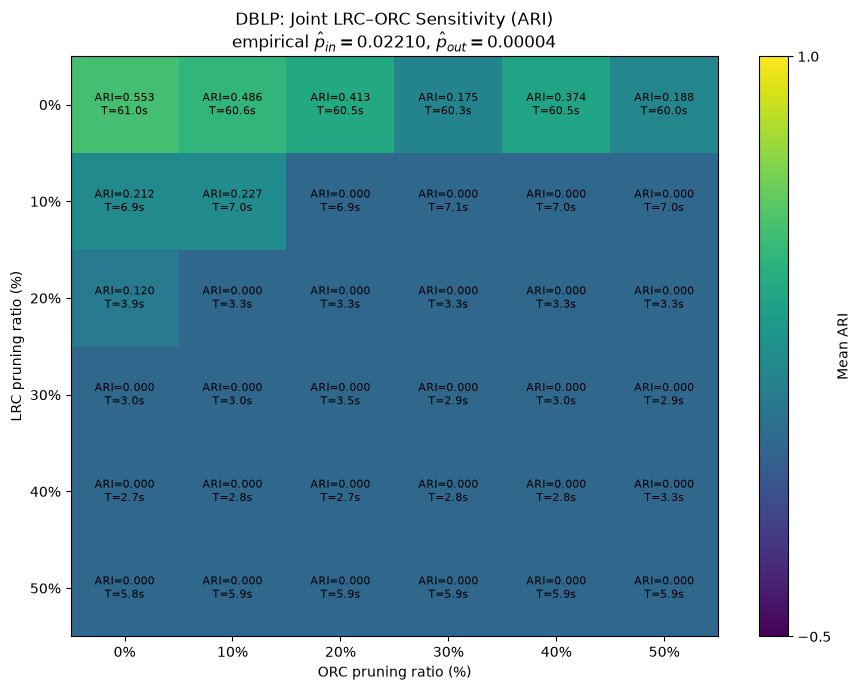

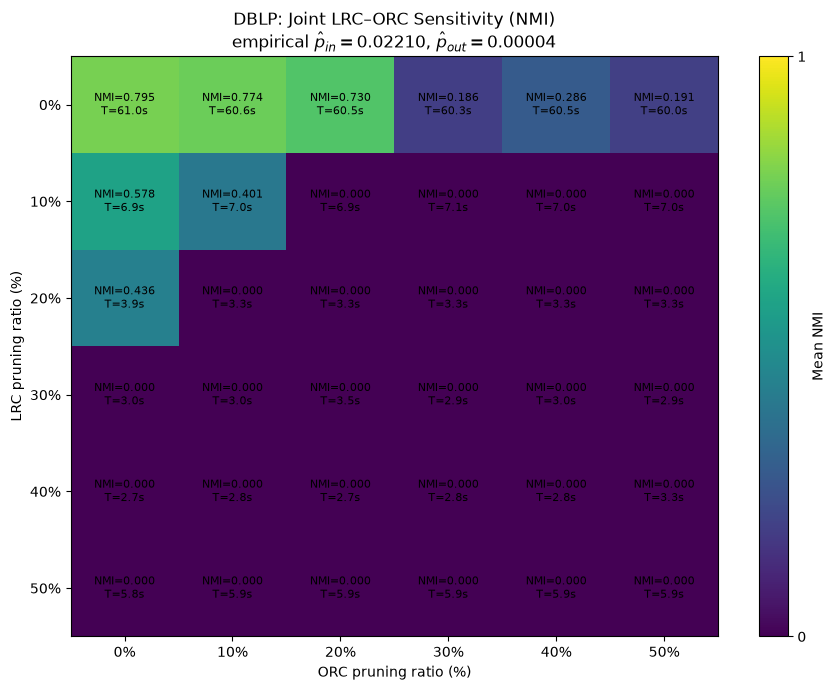


Saved:
  dblp_ari_lrc_orc_heatmap_with_runtime.png
  dblp_nmi_lrc_orc_heatmap_with_runtime.png
  dblp_lrc_orc_heatmap_summary.csv
  dblp_lrc_orc_heatmap_raw.csv
  dblp_empirical_pin_pout.csv


In [8]:
# ============================================================
# DBLP: JOINT LRC-ORC PRUNING HEATMAPS
# Each cell shows accuracy + runtime
# p_in and p_out are estimated from the actual DBLP benchmark
# ============================================================



# ------------------------------------------------------------
# 0. OUTPUT DIRECTORY
# ------------------------------------------------------------

OUTPUT_DIR = FIGURES_DIR

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 1. ESTIMATE EMPIRICAL p_in AND p_out FROM DBLP
# ============================================================

def estimate_empirical_pin_pout(
    graph,
    label_attribute="label_gt",
):

    labeled_nodes = [
        node
        for node in graph.nodes()
        if label_attribute in graph.nodes[node]
    ]

    labels = {
        node: graph.nodes[node][label_attribute]
        for node in labeled_nodes
    }

    # --------------------------------------------------------
    # Label sizes
    # --------------------------------------------------------

    label_counts = (
        pd.Series(
            list(labels.values())
        )
        .value_counts()
        .to_dict()
    )

    # --------------------------------------------------------
    # Possible within-label pairs
    # --------------------------------------------------------

    possible_within = sum(
        n * (n - 1) / 2
        for n in label_counts.values()
    )

    total_nodes = len(
        labeled_nodes
    )

    possible_total = (
        total_nodes
        * (total_nodes - 1)
        / 2
    )

    possible_between = (
        possible_total
        - possible_within
    )

    # --------------------------------------------------------
    # Observed within/between edges
    # --------------------------------------------------------

    observed_within = 0
    observed_between = 0

    labeled_set = set(
        labeled_nodes
    )

    for u, v in graph.edges():

        if (
            u not in labeled_set
            or v not in labeled_set
        ):
            continue

        if labels[u] == labels[v]:
            observed_within += 1
        else:
            observed_between += 1

    # --------------------------------------------------------
    # Empirical probabilities
    # --------------------------------------------------------

    p_in_hat = (
        observed_within
        / possible_within
        if possible_within > 0
        else np.nan
    )

    p_out_hat = (
        observed_between
        / possible_between
        if possible_between > 0
        else np.nan
    )

    return {
        "p_in":
            p_in_hat,

        "p_out":
            p_out_hat,

        "observed_within_edges":
            observed_within,

        "observed_between_edges":
            observed_between,

        "possible_within_pairs":
            possible_within,

        "possible_between_pairs":
            possible_between,

        "n_labeled":
            total_nodes,

        "n_labels":
            len(label_counts),
    }


dblp_structure = (
    estimate_empirical_pin_pout(
        H,
        label_attribute="label_gt",
    )
)


DBLP_PIN = (
    dblp_structure["p_in"]
)

DBLP_POUT = (
    dblp_structure["p_out"]
)


print("=" * 70)
print("DBLP EMPIRICAL STRUCTURE")
print("=" * 70)

print(
    f"Nodes       : "
    f"{dblp_structure['n_labeled']}"
)

print(
    f"Labels      : "
    f"{dblp_structure['n_labels']}"
)

print(
    f"Within edges: "
    f"{dblp_structure['observed_within_edges']}"
)

print(
    f"Between edges: "
    f"{dblp_structure['observed_between_edges']}"
)

print(
    f"Estimated p_in  = "
    f"{DBLP_PIN:.6f}"
)

print(
    f"Estimated p_out = "
    f"{DBLP_POUT:.6f}"
)


# ============================================================
# 2. HEATMAP SETTINGS
# ============================================================

LRC_HEAT_VALUES = [
    0,
    10,
    20,
    30,
    40,
    50,
]

ORC_HEAT_VALUES = [
    0,
    10,
    20,
    30,
    40,
    50,
]

HEATMAP_ALPHA = 0.5


# Match the existing DBLP experiment
HEATMAP_SEEDS = [
    0,
    1,
    2,
    3,
    4,
    42,
]


print("\n" + "=" * 70)
print("DBLP JOINT LRC-ORC SENSITIVITY")
print("=" * 70)

print(
    "LRC values:",
    LRC_HEAT_VALUES,
)

print(
    "ORC values:",
    ORC_HEAT_VALUES,
)

print(
    "alpha:",
    HEATMAP_ALPHA,
)

print(
    "seeds:",
    HEATMAP_SEEDS,
)


# ============================================================
# 3. RUN ALL LRC / ORC COMBINATIONS
# ============================================================

heatmap_rows = []


for lrc_pct in LRC_HEAT_VALUES:

    for orc_pct in ORC_HEAT_VALUES:

        print(
            f"\nRunning "
            f"LRC={lrc_pct}% | "
            f"ORC={orc_pct}% | "
            f"alpha={HEATMAP_ALPHA}"
        )

        # ----------------------------------------------------
        # Prepare graph ONCE for this pruning configuration
        # ----------------------------------------------------

        try:

            combo_info_heat = (
                cdu.prepare_combo_graph(
                    graph=H,
                    lrc_pct=lrc_pct,
                    orc_pct=orc_pct,
                    alpha=HEATMAP_ALPHA,
                    iterations=ORC_ITERATIONS,
                    method="Sinkhorn",
                    weight="weight",
                )
            )

        except Exception as error:

            print(
                "Preparation failed:",
                repr(error),
            )

            for seed in HEATMAP_SEEDS:

                heatmap_rows.append(
                    {
                        "seed":
                            seed,

                        "lrc_pct":
                            lrc_pct,

                        "orc_pct":
                            orc_pct,

                        "alpha":
                            HEATMAP_ALPHA,

                        "p_in":
                            DBLP_PIN,

                        "p_out":
                            DBLP_POUT,

                        "ARI":
                            np.nan,

                        "NMI":
                            np.nan,

                        "Runtime":
                            np.nan,

                        "Prep_time":
                            np.nan,

                        "Community_time":
                            np.nan,

                        "V":
                            np.nan,

                        "E":
                            np.nan,

                        "status":
                            "failed",
                    }
                )

            continue

        # ----------------------------------------------------
        # Evaluate with Louvain across seeds
        # ----------------------------------------------------

        for seed in HEATMAP_SEEDS:

            result = (
                cdu.evaluate_prepared_graph(
                    info=combo_info_heat,
                    algorithm="louvain",
                    seed=seed,
                    weight="weight",
                    label_attribute="label_gt",
                )
            )

            heatmap_rows.append(
                {
                    "seed":
                        seed,

                    "lrc_pct":
                        lrc_pct,

                    "orc_pct":
                        orc_pct,

                    "alpha":
                        HEATMAP_ALPHA,

                    "p_in":
                        DBLP_PIN,

                    "p_out":
                        DBLP_POUT,

                    "ARI":
                        result["ARI"],

                    "NMI":
                        result["NMI"],

                    "Runtime":
                        result["runtime_sec"],

                    "Prep_time":
                        result["prep_time"],

                    "Community_time":
                        result[
                            "community_time"
                        ],

                    "V":
                        result["V"],

                    "E":
                        result["E"],

                    "status":
                        "ok",
                }
            )


df_dblp_heatmap_raw = (
    pd.DataFrame(
        heatmap_rows
    )
)


# ============================================================
# 4. SUMMARY ACROSS RANDOM SEEDS
# ============================================================

df_dblp_heatmap_valid = (
    df_dblp_heatmap_raw[
        df_dblp_heatmap_raw[
            "status"
        ] == "ok"
    ]
    .copy()
)


dblp_heatmap_summary = (
    df_dblp_heatmap_valid
    .groupby(
        [
            "lrc_pct",
            "orc_pct",
        ],
        as_index=False,
    )
    .agg(

        ARI_mean=(
            "ARI",
            "mean",
        ),

        ARI_std=(
            "ARI",
            "std",
        ),

        NMI_mean=(
            "NMI",
            "mean",
        ),

        NMI_std=(
            "NMI",
            "std",
        ),

        Runtime_mean=(
            "Runtime",
            "mean",
        ),

        Runtime_std=(
            "Runtime",
            "std",
        ),

        Prep_time_mean=(
            "Prep_time",
            "mean",
        ),

        Community_time_mean=(
            "Community_time",
            "mean",
        ),

        V_mean=(
            "V",
            "mean",
        ),

        E_mean=(
            "E",
            "mean",
        ),
    )
)


print(
    "\nDBLP joint sensitivity summary:"
)

display(
    dblp_heatmap_summary
)


# ============================================================
# 5. CREATE MATRICES
# ============================================================

def make_heatmap_matrix(
    dataframe,
    value_column,
):

    return (
        dataframe
        .pivot(
            index="lrc_pct",
            columns="orc_pct",
            values=value_column,
        )
        .reindex(
            index=LRC_HEAT_VALUES,
            columns=ORC_HEAT_VALUES,
        )
    )


ari_matrix = (
    make_heatmap_matrix(
        dblp_heatmap_summary,
        "ARI_mean",
    )
)


nmi_matrix = (
    make_heatmap_matrix(
        dblp_heatmap_summary,
        "NMI_mean",
    )
)


runtime_matrix = (
    make_heatmap_matrix(
        dblp_heatmap_summary,
        "Runtime_mean",
    )
)


# ============================================================
# 6. HEATMAP FUNCTION
#    COLOR = ACCURACY
#    CELL TEXT = ACCURACY + TIME
# ============================================================

def plot_dblp_metric_heatmap(
    metric_matrix,
    runtime_matrix,
    metric_name,
):

    fig, ax = plt.subplots(
        figsize=(9, 7)
    )

    # --------------------------------------------------------
    # Metric-specific color scale
    # --------------------------------------------------------

    if metric_name == "ARI":

        vmin = -0.5
        vmax = 1.0

        colorbar_ticks = [
            -0.5,
            1.0,
        ]

    elif metric_name == "NMI":

        vmin = 0.0
        vmax = 1.0

        colorbar_ticks = [
            0.0,
            1.0,
        ]

    else:

        vmin = None
        vmax = None
        colorbar_ticks = None

    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    im = ax.imshow(
        metric_matrix.values,
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )

    # --------------------------------------------------------
    # X axis = ORC
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(
            len(
                ORC_HEAT_VALUES
            )
        )
    )

    ax.set_xticklabels(
        [
            f"{value}%"
            for value
            in ORC_HEAT_VALUES
        ]
    )

    # --------------------------------------------------------
    # Y axis = LRC
    # --------------------------------------------------------

    ax.set_yticks(
        np.arange(
            len(
                LRC_HEAT_VALUES
            )
        )
    )

    ax.set_yticklabels(
        [
            f"{value}%"
            for value
            in LRC_HEAT_VALUES
        ]
    )

    ax.set_xlabel(
        "ORC pruning ratio (%)"
    )

    ax.set_ylabel(
        "LRC pruning ratio (%)"
    )

    ax.set_title(
        f"DBLP: Joint LRC–ORC Sensitivity ({metric_name})\n"
        f"empirical "
        f"$\\hat{{p}}_{{in}}={DBLP_PIN:.5f}$, "
        f"$\\hat{{p}}_{{out}}={DBLP_POUT:.5f}$"
    )

    # --------------------------------------------------------
    # Cell annotation
    # --------------------------------------------------------

    for i, lrc_pct in enumerate(
        LRC_HEAT_VALUES
    ):

        for j, orc_pct in enumerate(
            ORC_HEAT_VALUES
        ):

            metric_value = (
                metric_matrix.loc[
                    lrc_pct,
                    orc_pct
                ]
            )

            runtime_value = (
                runtime_matrix.loc[
                    lrc_pct,
                    orc_pct
                ]
            )

            if (
                pd.isna(metric_value)
                or pd.isna(runtime_value)
            ):

                text = "failed"

            else:

                text = (
                    f"{metric_name}="
                    f"{metric_value:.3f}\n"
                    f"T="
                    f"{runtime_value:.1f}s"
                )

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=8,
            )

    # --------------------------------------------------------
    # Colorbar
    # --------------------------------------------------------

    cbar = fig.colorbar(
        im,
        ax=ax,
    )

    if colorbar_ticks is not None:
        cbar.set_ticks(
            colorbar_ticks
        )

    cbar.set_label(
        f"Mean {metric_name}"
    )

    fig.tight_layout()

    return fig


# ============================================================
# 7. ARI HEATMAP
# ============================================================

fig_ari = (
    plot_dblp_metric_heatmap(
        metric_matrix=
            ari_matrix,

        runtime_matrix=
            runtime_matrix,

        metric_name=
            "ARI",
    )
)


plt.show()


# ============================================================
# 8. NMI HEATMAP
# ============================================================

fig_nmi = (
    plot_dblp_metric_heatmap(
        metric_matrix=
            nmi_matrix,

        runtime_matrix=
            runtime_matrix,

        metric_name=
            "NMI",
    )
)


plt.show()


# ============================================================
# 9. SAVE RESULTS
# ============================================================

fig_ari.savefig(
    FIGURES_DIR
    / "dblp_ari_lrc_orc_heatmap_with_runtime.png",
    dpi=300,
    bbox_inches="tight",
)


fig_nmi.savefig(
    FIGURES_DIR
    / "dblp_nmi_lrc_orc_heatmap_with_runtime.png",
    dpi=300,
    bbox_inches="tight",
)


dblp_heatmap_summary.to_csv(
    SENSITIVITY_DIR
    / "dblp_lrc_orc_heatmap_summary.csv",
    index=False,
)


df_dblp_heatmap_raw.to_csv(
    SENSITIVITY_DIR
    / "dblp_lrc_orc_heatmap_raw.csv",
    index=False,
)


pd.DataFrame(
    [dblp_structure]
).to_csv(
    TABLES_DIR
    / "dblp_empirical_pin_pout.csv",
    index=False,
)


plt.close(
    fig_ari
)

plt.close(
    fig_nmi
)


print("\nSaved:")

print(
    "  dblp_ari_lrc_orc_heatmap_with_runtime.png"
)

print(
    "  dblp_nmi_lrc_orc_heatmap_with_runtime.png"
)

print(
    "  dblp_lrc_orc_heatmap_summary.csv"
)

print(
    "  dblp_lrc_orc_heatmap_raw.csv"
)

print(
    "  dblp_empirical_pin_pout.csv"
)


DBLP
empirical p_in  = 0.022098
empirical p_out = 0.000042

DBLP | LRC=0% | ORC=0%
seed=0 | ARI=0.573 | NMI=0.791 | T=60.02s
seed=1 | ARI=0.545 | NMI=0.799 | T=60.51s

DBLP | LRC=0% | ORC=5%
seed=0 | ARI=0.532 | NMI=0.783 | T=60.00s
seed=1 | ARI=0.511 | NMI=0.784 | T=59.53s

DBLP | LRC=0% | ORC=10%
seed=0 | ARI=0.481 | NMI=0.772 | T=60.05s
seed=1 | ARI=0.498 | NMI=0.778 | T=60.06s

DBLP | LRC=0% | ORC=20%
seed=0 | ARI=0.416 | NMI=0.732 | T=59.03s
seed=1 | ARI=0.411 | NMI=0.728 | T=59.03s

DBLP | LRC=0% | ORC=30%
seed=0 | ARI=0.160 | NMI=0.178 | T=59.16s
seed=1 | ARI=0.189 | NMI=0.194 | T=59.16s

DBLP | LRC=5% | ORC=0%
seed=0 | ARI=0.423 | NMI=0.764 | T=25.39s
seed=1 | ARI=0.416 | NMI=0.764 | T=25.41s

DBLP | LRC=5% | ORC=5%
seed=0 | ARI=0.395 | NMI=0.740 | T=24.76s
seed=1 | ARI=0.378 | NMI=0.731 | T=24.76s

DBLP | LRC=5% | ORC=10%
seed=0 | ARI=0.264 | NMI=0.638 | T=25.47s
seed=1 | ARI=0.265 | NMI=0.639 | T=25.47s

DBLP | LRC=5% | ORC=20%
seed=0 | ARI=0.189 | NMI=0.512 | T=24.76s
seed=

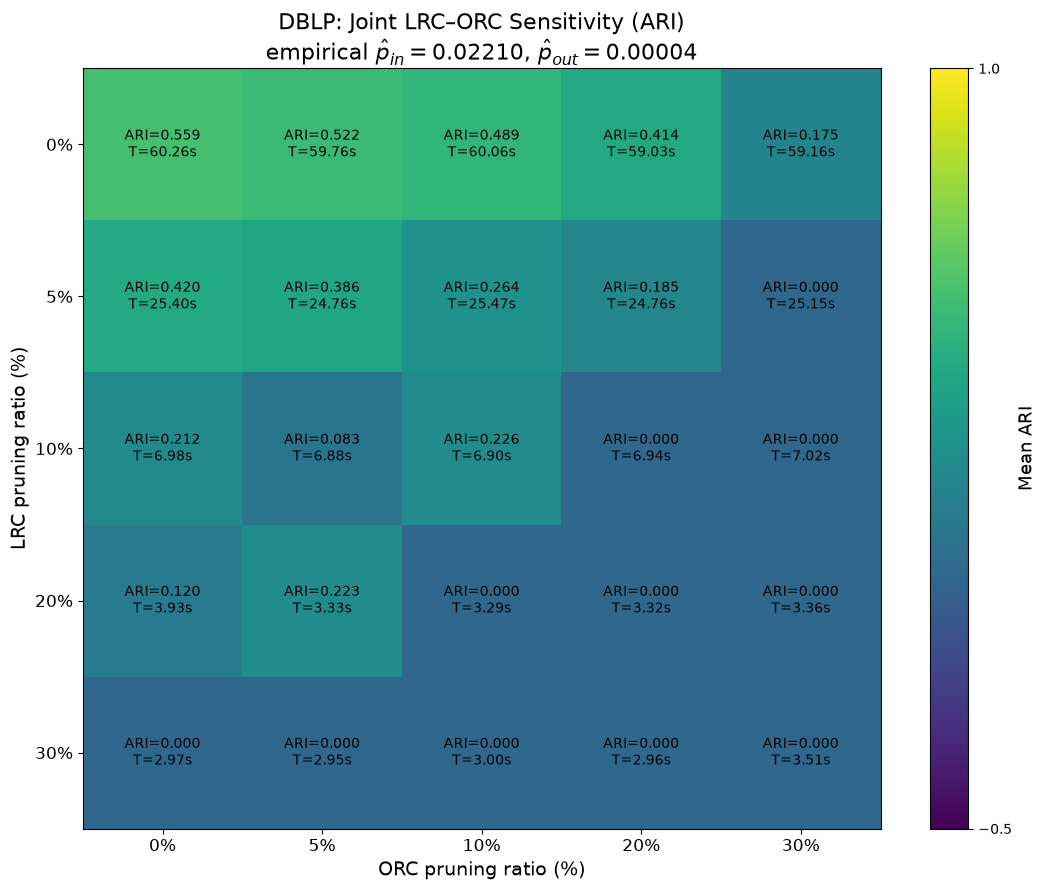

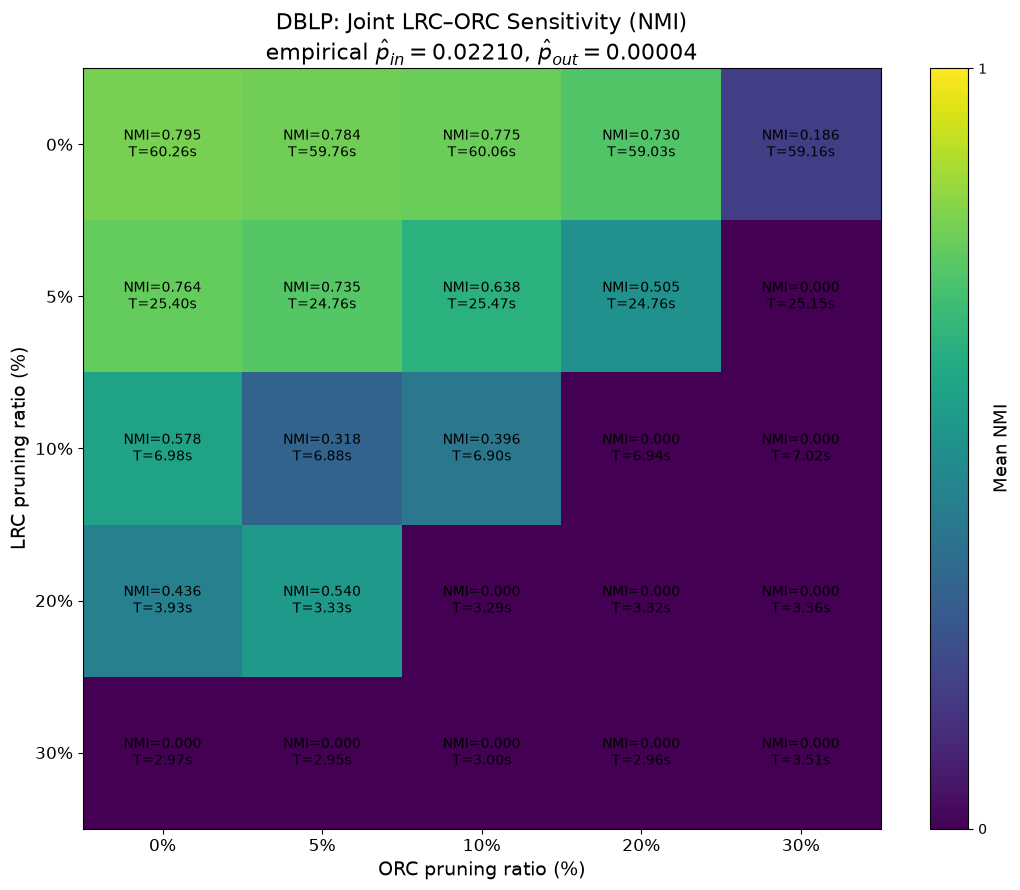

In [9]:
dblp_raw, dblp_summary = cdu.run_real_dataset_heatmap(
    H,
    "DBLP",
    orc_iterations=5
)